# 165 — Selected video frames and named-event waveforms

This notebook creates a publication figure that pairs manually selected frames
from the authorized local USLaunchReport recording with event-centred BCHH
pressure waveforms. Its two deliberate stages are:

1. generate native-frame contact sheets around each visual target; and
2. render the final composite using the small editable selection table below.

The figure uses the video anchor and named source times from
`project_config.py`, the timestamp-aware PyAV approach used by Notebook 160,
and the baseline/arrival/window conventions used by Notebook 124. The four
waveform panels are independently scaled so the approximately 1.5 kPa
principal explosion does not obscure the smaller named events.

The copyrighted source movie is not redistributed. Selected frames are used
only in the publication figure and candidate sheets written to Notebook 165's
standard output directory.

Canonical notebook: consolidated from the `figure1` variant, with explicit DD1/DD3/DD2 drawing order and line-style provenance. Do not run the two historical 165 variants against the same output directory. This display follows sensor-relative 124 conventions; it does not reproduce 110's unshifted scalar measurement support.


In [1]:
from __future__ import annotations

import json
import hashlib
import sys
from pathlib import Path

import av
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from obspy import UTCDateTime, read


def find_project_root(start: Path) -> Path:
    """Find the repository root from either the root or notebooks directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "modules" / "project_config.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find modules/project_config.py above the working directory. "
        "Run this notebook from the repository root or notebooks directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modules import project_config as config

print("Project root:", PROJECT_ROOT)
print("Configuration:", config.__file__)


def file_fingerprint(path):
    path = Path(path)
    stat = path.stat()
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return {"sha256": digest.hexdigest(), "size_bytes": stat.st_size}

def write_review_json(path, value):
    """Preserve the previous manual product before replacing it."""
    path = Path(path)
    if path.exists():
        from datetime import datetime, timezone
        import shutil
        stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        shutil.copy2(path, path.with_name(path.stem + ".backup_" + stamp + path.suffix))
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")
    temporary.replace(path)


Project root: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0
Configuration: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/modules/project_config.py


## 1. Controls you will normally edit

`FRAME_SELECTIONS` contains one unobstructed video frame for each of the four
composite event panels. Each visual selection is an explicit native **movie
PTS**, so changing a frame never changes the physical event time used to align
the pressure records. The principal- and payload-explosion frames are
deliberately selected after their inferred origins so that the fireballs and
fragments are visually developed; the falling-payload frame is deliberately
before impact.

Run the contact-sheet section, inspect the labelled candidates, then copy the
preferred candidate's exact `PTS` into `selected_movie_pts_s`. Exact movie PTS
values remain in the audit and provenance products but are omitted from the
publication figure itself.


In [2]:
UPPER_STAGE_UTC = UTCDateTime(config.SOURCE_EVENT_TIMES["upper_stage"])
LOWER_STAGE_UTC = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])
PAYLOAD_IMPACT_UTC = UTCDateTime(config.SOURCE_EVENT_TIMES["payload_impact"])
PAYLOAD_EXPLOSION_UTC = UTCDateTime(
    config.SOURCE_EVENT_TIMES["payload_explosion"]
)

SOURCE_TIMES = {
    "upper_stage": UPPER_STAGE_UTC,
    "lower_stage": LOWER_STAGE_UTC,
    "payload_impact": PAYLOAD_IMPACT_UTC,
    "payload_explosion": PAYLOAD_EXPLOSION_UTC,
}

# -------------------------------------------------------------------------
# EDIT ONLY `selected_movie_pts_s` AFTER INSPECTING THE CONTACT SHEETS.
# These are visual selections, not estimates of physical event origin time.
# -------------------------------------------------------------------------
FRAME_SELECTIONS = [
    {
        "key": "upper_stage_after",
        "panel_label": "Upper-stage failure",
        "description": "First visible upper-stage explosion",
        "event_key": "upper_stage",
        "selected_movie_pts_s": 71.738,
        "candidate_half_width_s": 0.20,
    },
    {
        "key": "principal_explosion",
        "panel_label": "Principal explosion",
        "description": "Developed principal/lower-stage fireball",
        "event_key": "lower_stage",
        "selected_movie_pts_s": 75.842,
        "candidate_half_width_s": 0.35,
    },
    {
        "key": "falling_payload",
        "panel_label": "Payload fall and impact",
        "description": "Payload/fairing close to the ground before impact",
        "event_key": "payload_impact",
        "selected_movie_pts_s": 83.350,
        "candidate_half_width_s": 0.75,
    },
    {
        "key": "payload_fragments",
        "panel_label": "Payload explosion",
        "description": "Developed payload fireball and ejected fragments",
        "event_key": "payload_explosion",
        "selected_movie_pts_s": 84.885,
        "candidate_half_width_s": 0.50,
    },
]

EVENT_PLOT_SPECS = [
    ("upper_stage", "Upper-stage failure"),
    ("lower_stage", "Principal explosion"),
    ("payload_impact", "Payload impact"),
    ("payload_explosion", "Payload explosion"),
]

# Frame-selection products.
GENERATE_FRAME_CONTACT_SHEETS = True
CONTACT_SHEET_COLUMNS = 7
CONTACT_SHEET_DPI = 150

# Final-figure choices.
INCLUDE_SEISMIC = False  # publication figure is pressure-only
REMOVE_SEISMIC_DISPLAY_MEDIAN = True
VIDEO_CROP_PIXELS = None  # (left, right, top, bottom), or None
FINAL_FIGURE_DPI = 250

# Optional event-specific display limits relative to predicted channel arrival.
# Leave a value as None to use Notebook 124's reviewed baseline-to-signal span.
EVENT_XLIMIT_OVERRIDES_S = {
    "upper_stage": None,
    "lower_stage": None,
    "payload_impact": None,
    "payload_explosion": None,
}

# Notebook 124 extends the payload-impact interval slightly before time zero so
# its leading compression is not clipped after adoption of 351 m/s.
SIGNAL_START_OFFSET_OVERRIDES_S = {}  # authoritative offsets come from 110

PRESSURE_LINE_STYLES = {
    "DD1": dict(
        color="#D55E00", lw=0.65, ls=":", alpha=0.75, zorder=1
    ),
    "DD3": dict(
        color="#009E73", lw=0.70, ls="-.", alpha=0.80, zorder=2
    ),
    "DD2": dict(
        color="#0072B2", lw=1.10, ls="-", alpha=1.00, zorder=3
    ),
}

PRESSURE_PLOT_ORDER = ("DD1", "DD3", "DD2")
SEISMIC_CHANNELS = ()

display(pd.DataFrame(FRAME_SELECTIONS))


,key,panel_label,description,event_key,selected_movie_pts_s,candidate_half_width_s
0,upper_stage_after,Upper-stage failure,First visible upper-stage explosion,upper_stage,71.738,0.20
1,principal_explosion,Principal explosion,Developed principal/lower-stage fireball,lower_stage,75.842,0.35
2,falling_payload,Payload fall and impact,Payload/fairing close to the ground before impact,payload_impact,83.350,0.75
3,payload_fragments,Payload explosion,Developed payload fireball and ejected fragments,payload_explosion,84.885,0.50


## 2. Resolve and validate inputs

Notebook 110 supplies the reviewed named-event windows and channel distances;
Notebook 124 uses these same products for baseline correction, acoustic
arrival alignment, and energetics. The baseline-corrected stream from Notebook
010 contains the pressure and seismic channels.


In [3]:
if config.USLAUNCHREPORT_VIDEO_FILE is None:
    raise RuntimeError(
        "Set external_paths.uslaunchreport_video_file in "
        f"{config.LOCAL_CONFIG_FILE} to an authorized local copy of the "
        "USLaunchReport source movie."
    )

VIDEO_FILE = Path(config.USLAUNCHREPORT_VIDEO_FILE)
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
WINDOW_FILE = config.NB110_DIR / "key_event_measurement_windows.csv"
MEASUREMENT_METADATA_FILE = (
    config.NB110_DIR / "key_event_measurement_metadata.json"
)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
measurement_metadata = json.loads(MEASUREMENT_METADATA_FILE.read_text())
baseline_products = analysis_config.get("baseline_removed_streams", {})
WAVEFORM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
GEOMETRY_FILE = Path(analysis_config["geometry_file"]).expanduser()

OUTDIR = config.notebook_output_dir(165, "generate_video_waveform_figure")
CONTACT_SHEET_DIR = OUTDIR / "frame_selection_contact_sheets"
OUTDIR.mkdir(parents=True, exist_ok=True)
CONTACT_SHEET_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_FILE = OUTDIR / "165_video_named_event_waveforms.pdf"
FIGURE_PREVIEW_FILE = OUTDIR / "165_video_named_event_waveforms.png"
AUDIT_FILE = OUTDIR / "165_video_named_event_waveforms_audit.csv"
PROVENANCE_FILE = OUTDIR / "165_video_named_event_waveforms_provenance.json"

required_inputs = {
    "USLaunchReport movie": VIDEO_FILE,
    "analysis configuration": ANALYSIS_CONFIG_FILE,
    "baseline-corrected waveform stream": WAVEFORM_FILE,
    "channel geometry": GEOMETRY_FILE,
    "weather summary": WEATHER_FILE,
    "named-event measurement windows": WINDOW_FILE,
    "named-event measurement metadata": MEASUREMENT_METADATA_FILE,
}
for label, path in required_inputs.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing {label}: {path}")

if INCLUDE_SEISMIC:
    raise NotImplementedError("This canonical composite is pressure-only; no seismic row is implemented.")
windows = pd.read_csv(WINDOW_FILE)
weather = pd.read_csv(WEATHER_FILE).iloc[0]
stream = read(str(WAVEFORM_FILE), format="PICKLE")

PRESSURE_CHANNELS = tuple(analysis_config["pressure_channels"])
PRESSURE_DISTANCES_M = {
    str(channel).upper(): float(distance)
    for channel, distance in measurement_metadata["sensor_distances_m"].items()
}
ACOUSTIC_REDUCTION_SPEED_MPS = float(
    measurement_metadata["acoustic_propagation_speed_mps"]
)
meteorological_speed_mps = float(weather["effective_sound_speed_mps"])

if not np.isclose(ACOUSTIC_REDUCTION_SPEED_MPS, 351.0, atol=0.1):
    raise ValueError(
        "Notebook 110 does not use the adopted approximately 351 m/s "
        f"source-to-array speed: {ACOUSTIC_REDUCTION_SPEED_MPS:.3f}"
    )
if abs(meteorological_speed_mps - ACOUSTIC_REDUCTION_SPEED_MPS) > 0.25:
    raise ValueError(
        "Notebook 110's adopted speed is inconsistent with Notebook 020: "
        f"{ACOUSTIC_REDUCTION_SPEED_MPS:.3f} versus "
        f"{meteorological_speed_mps:.3f} m/s"
    )

geometry = pd.read_csv(GEOMETRY_FILE)
geometry["channel"] = geometry["channel"].astype(str).str.upper()
DISTANCE_BY_CHANNEL_M = (
    geometry.set_index("channel")["distance_m"].astype(float).to_dict()
)

for channel in PRESSURE_CHANNELS:
    if channel not in PRESSURE_DISTANCES_M:
        raise KeyError(f"Notebook 110 metadata lacks distance for {channel}")
if INCLUDE_SEISMIC:
    for channel in SEISMIC_CHANNELS:
        if channel not in DISTANCE_BY_CHANNEL_M:
            raise KeyError(f"Geometry table lacks distance for {channel}")

available_window_keys = set(windows["source_event_key"].astype(str))
missing_window_keys = {
    event_key for event_key, _ in EVENT_PLOT_SPECS
    if event_key not in available_window_keys
}
if missing_window_keys:
    raise KeyError(
        "Named-event window table lacks: " + ", ".join(sorted(missing_window_keys))
    )

print("Video:", VIDEO_FILE)
print("Waveforms:", WAVEFORM_FILE)
print("Output directory:", OUTDIR)
print(
    "Meteorological estimate / adopted reduction: "
    f"{meteorological_speed_mps:.2f} / "
    f"{ACOUSTIC_REDUCTION_SPEED_MPS:.1f} m/s"
)

if abs(float(UTCDateTime(config.VIDEO_ANCHOR_UTC) - UPPER_STAGE_UTC)) > 1e-6:
    raise ValueError("Configured video anchor must map to upper-stage source time")


Video: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/SpaceX - Static Fire Anomaly - AMOS-6 - 09-01-2016.mov
Waveforms: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Output directory: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure
Meteorological estimate / adopted reduction: 350.98 / 351.0 m/s


## 3. Timestamp-aware native video reader

As in Notebook 160, PyAV seeks using presentation timestamps and returns the
decoded source frame nearest the requested movie time. The final audit records
both requested and actual PTS values, so native-frame quantization remains
explicit.


In [4]:
class NativeVideoReader:
    """Read the local video frame nearest a requested native movie PTS."""

    def __init__(self, path: Path):
        self.path = Path(path)
        self.container = av.open(str(self.path))
        self.stream = self.container.streams.video[0]
        self.stream.thread_type = "AUTO"
        self.nominal_fps = (
            float(self.stream.average_rate)
            if self.stream.average_rate is not None
            else float(config.VIDEO_NOMINAL_FPS)
        )
        self.duration_s = (
            float(self.stream.duration * self.stream.time_base)
            if self.stream.duration is not None
            else None
        )

    def close(self):
        self.container.close()

    def frame_at_pts(self, requested_pts_s: float):
        if requested_pts_s < 0:
            raise ValueError(f"Negative movie PTS requested: {requested_pts_s}")
        if self.duration_s is not None and requested_pts_s > self.duration_s:
            raise ValueError(
                f"Movie PTS {requested_pts_s:.3f} exceeds duration "
                f"{self.duration_s:.3f} s"
            )

        seek_pts = int(requested_pts_s / float(self.stream.time_base))
        self.container.seek(
            max(0, seek_pts),
            stream=self.stream,
            backward=True,
            any_frame=False,
        )

        nearest_frame = None
        nearest_pts_s = np.nan
        nearest_error_s = np.inf
        for frame in self.container.decode(self.stream):
            if frame.pts is None:
                continue
            frame_pts_s = float(frame.pts * frame.time_base)
            error_s = abs(frame_pts_s - requested_pts_s)
            if error_s < nearest_error_s:
                nearest_frame = frame
                nearest_pts_s = frame_pts_s
                nearest_error_s = error_s
            if frame_pts_s >= requested_pts_s:
                break

        if nearest_frame is None:
            raise RuntimeError(
                f"No video frame decoded near PTS={requested_pts_s:.6f} s"
            )
        image = nearest_frame.to_ndarray(format="rgb24")
        if VIDEO_CROP_PIXELS is not None:
            left, right, top, bottom = VIDEO_CROP_PIXELS
            image = image[top:bottom, left:right]
        return image, float(nearest_pts_s), float(nearest_error_s)


def event_source_offset_s(event_key: str) -> float:
    return float(SOURCE_TIMES[event_key] - UPPER_STAGE_UTC)


def requested_movie_pts_s(selection: dict) -> float:
    """Return the explicitly selected native movie PTS."""
    return float(selection["selected_movie_pts_s"])


video_reader = NativeVideoReader(VIDEO_FILE)
native_frame_interval_s = 1.0 / video_reader.nominal_fps
print(f"Native nominal FPS: {video_reader.nominal_fps:.8f}")
print(f"Native nominal frame interval: {native_frame_interval_s:.6f} s")


Native nominal FPS: 29.97002997
Native nominal frame interval: 0.033367 s


## 4. Generate candidate-frame contact sheets

Each sheet samples every nominal native-frame interval around the current
selection. The green border identifies the frame currently requested by
`FRAME_SELECTIONS`; nearby candidates are labelled with their actual PTS,
offset from the relevant named event, and source-relative time. Because PyAV
reports the decoded PTS, duplicate native frames are removed automatically.


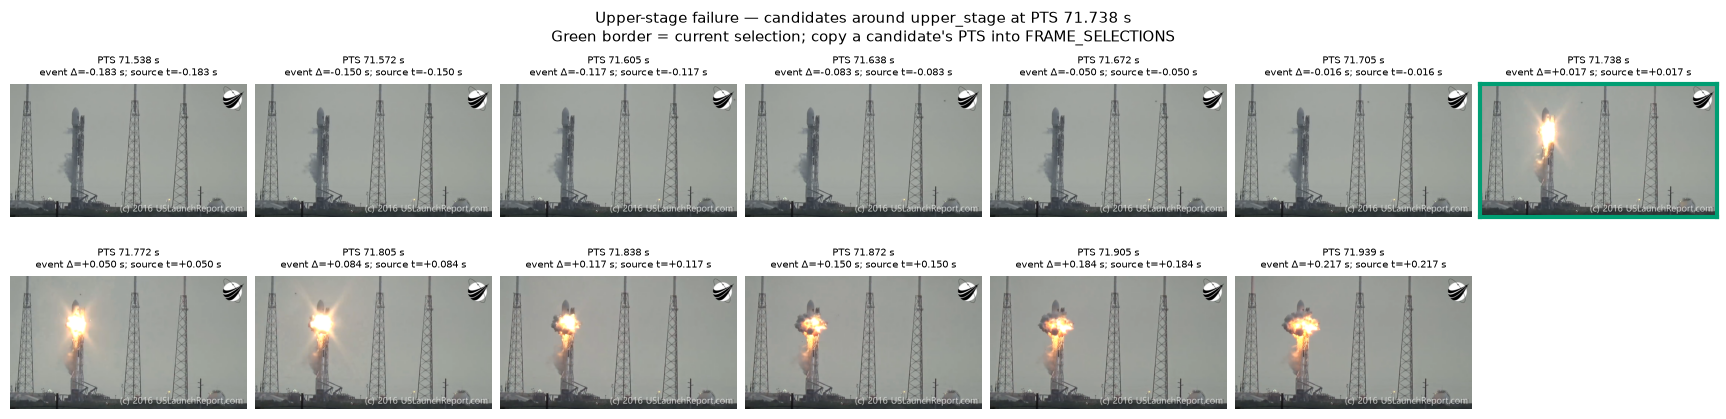

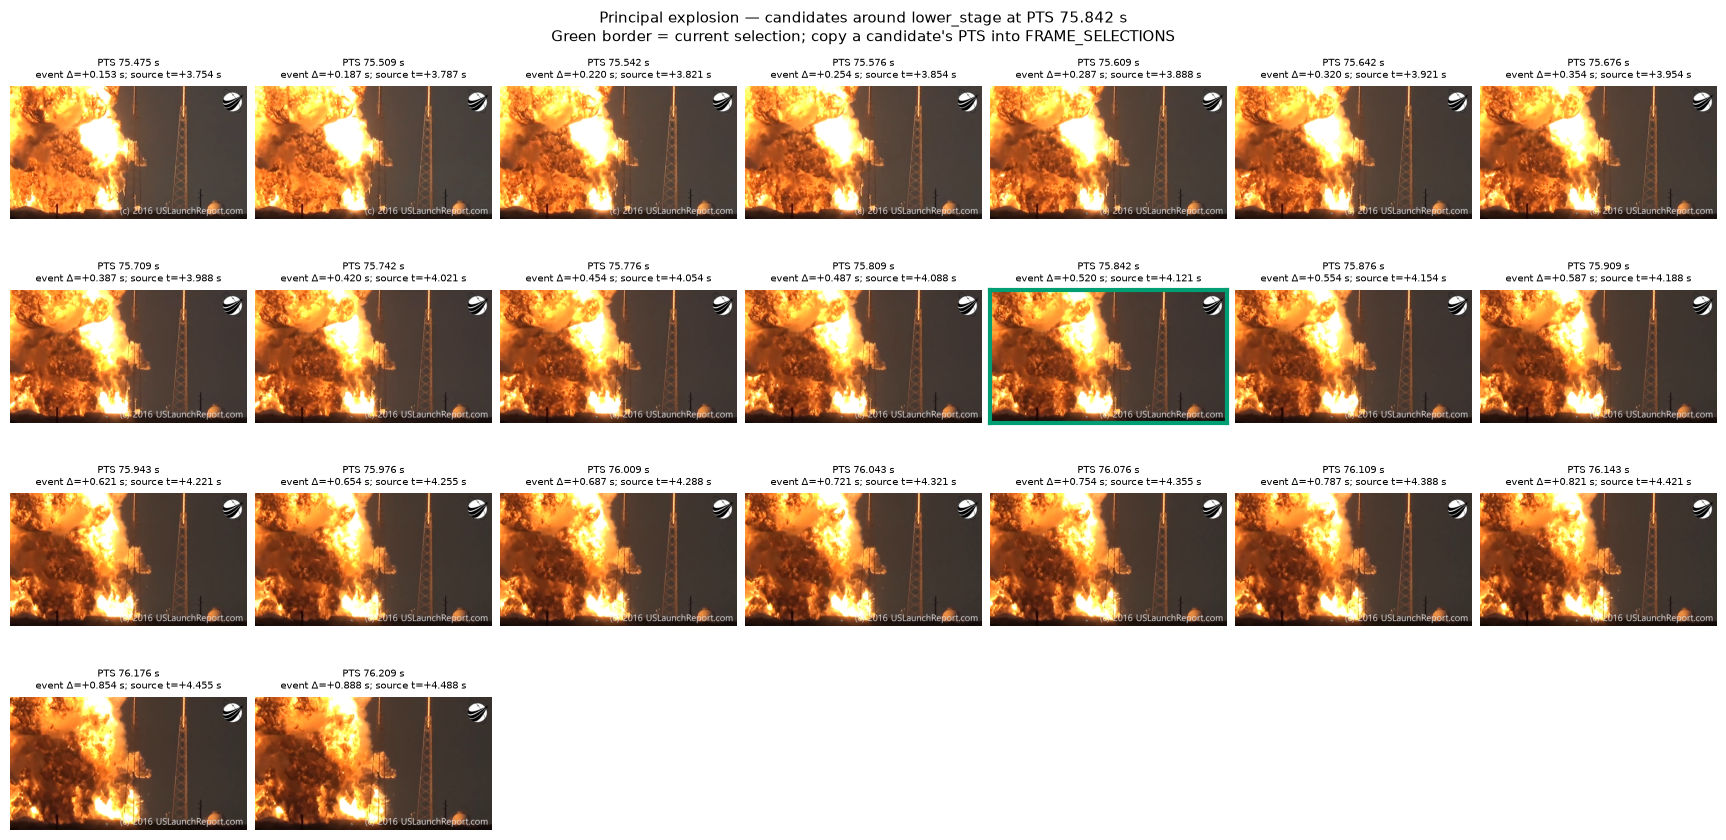

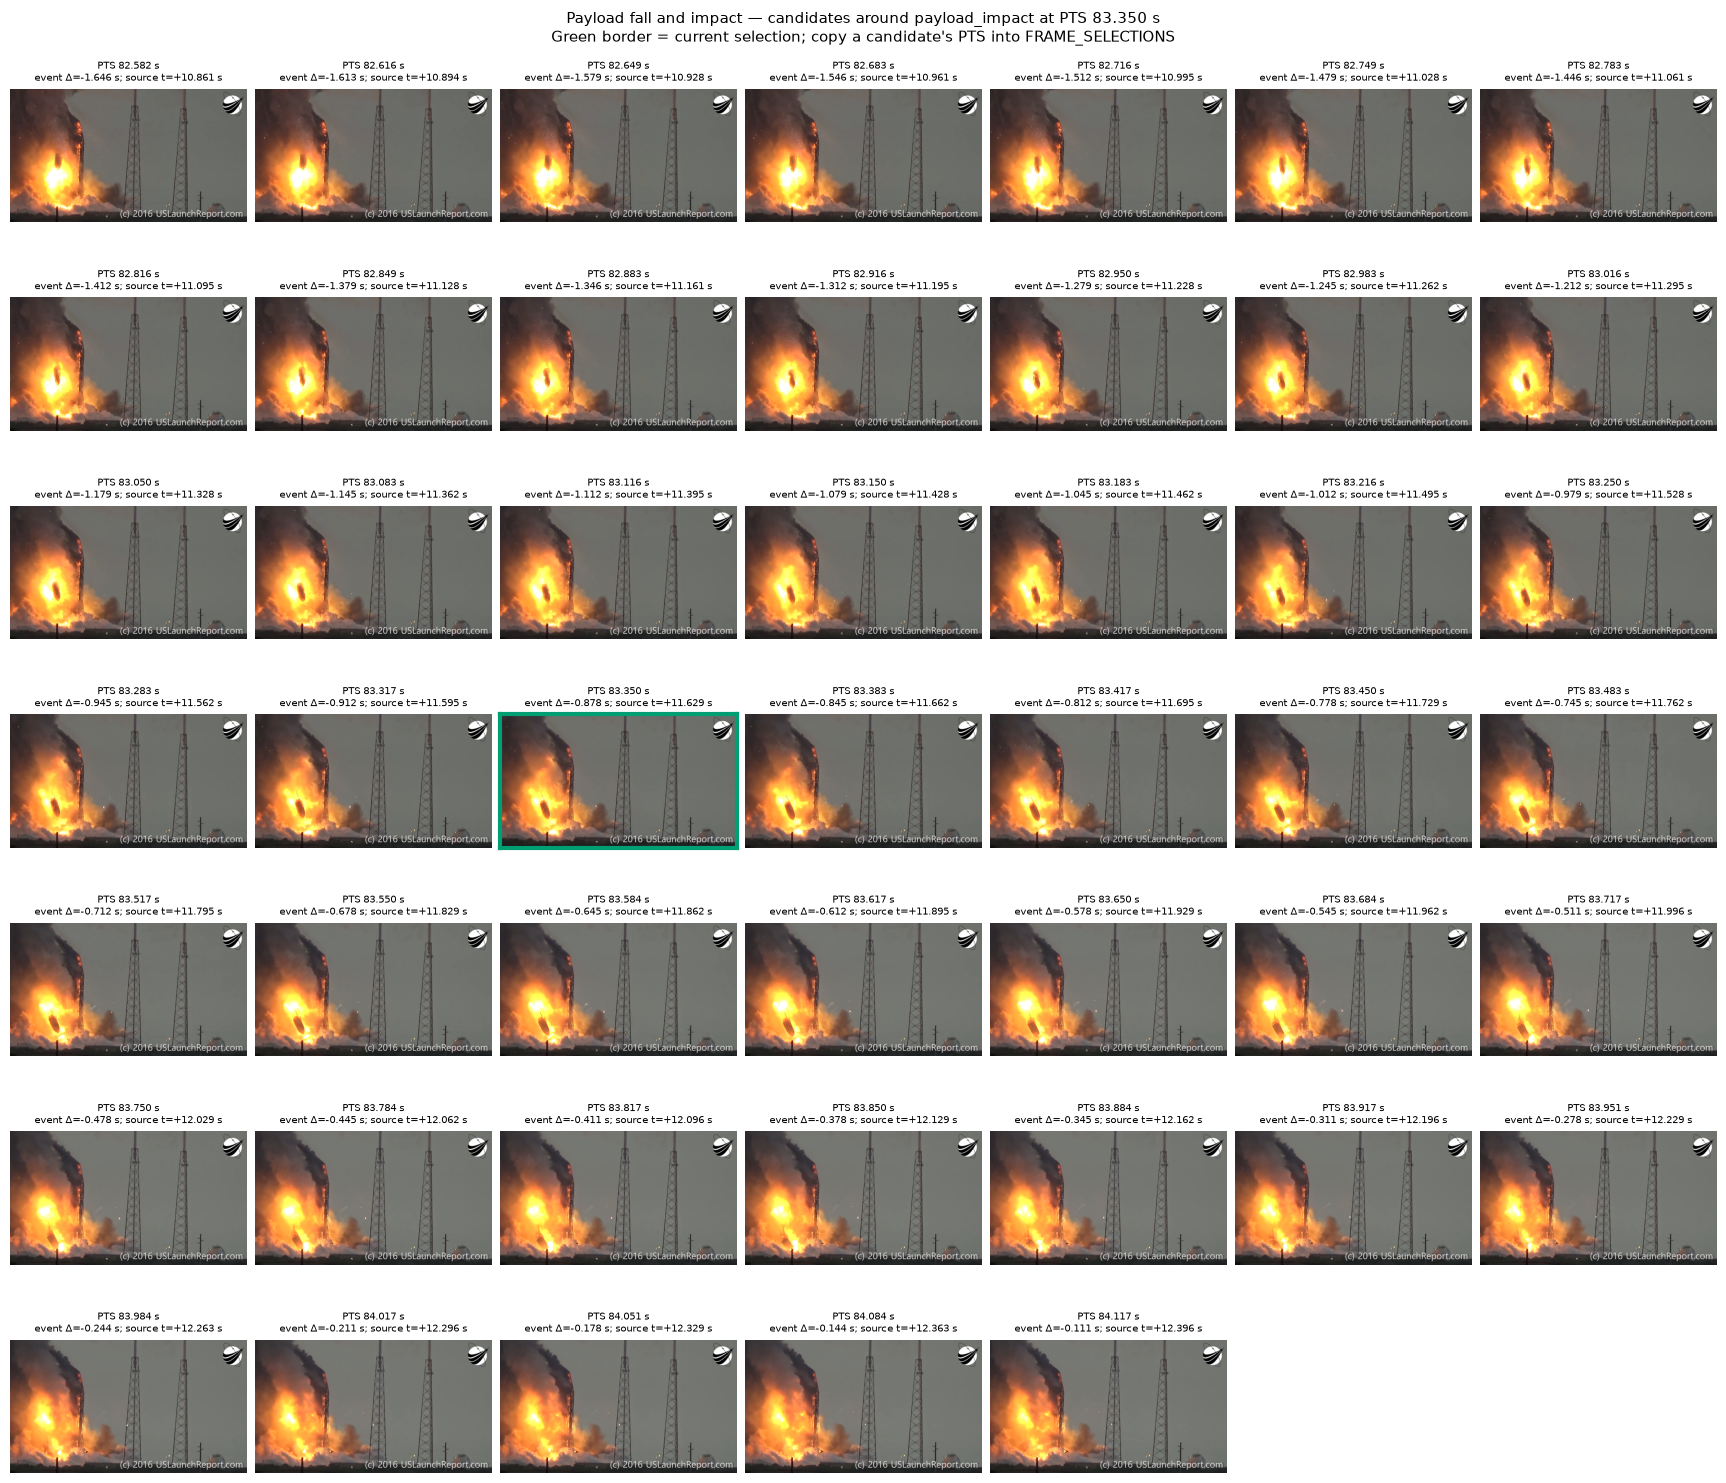

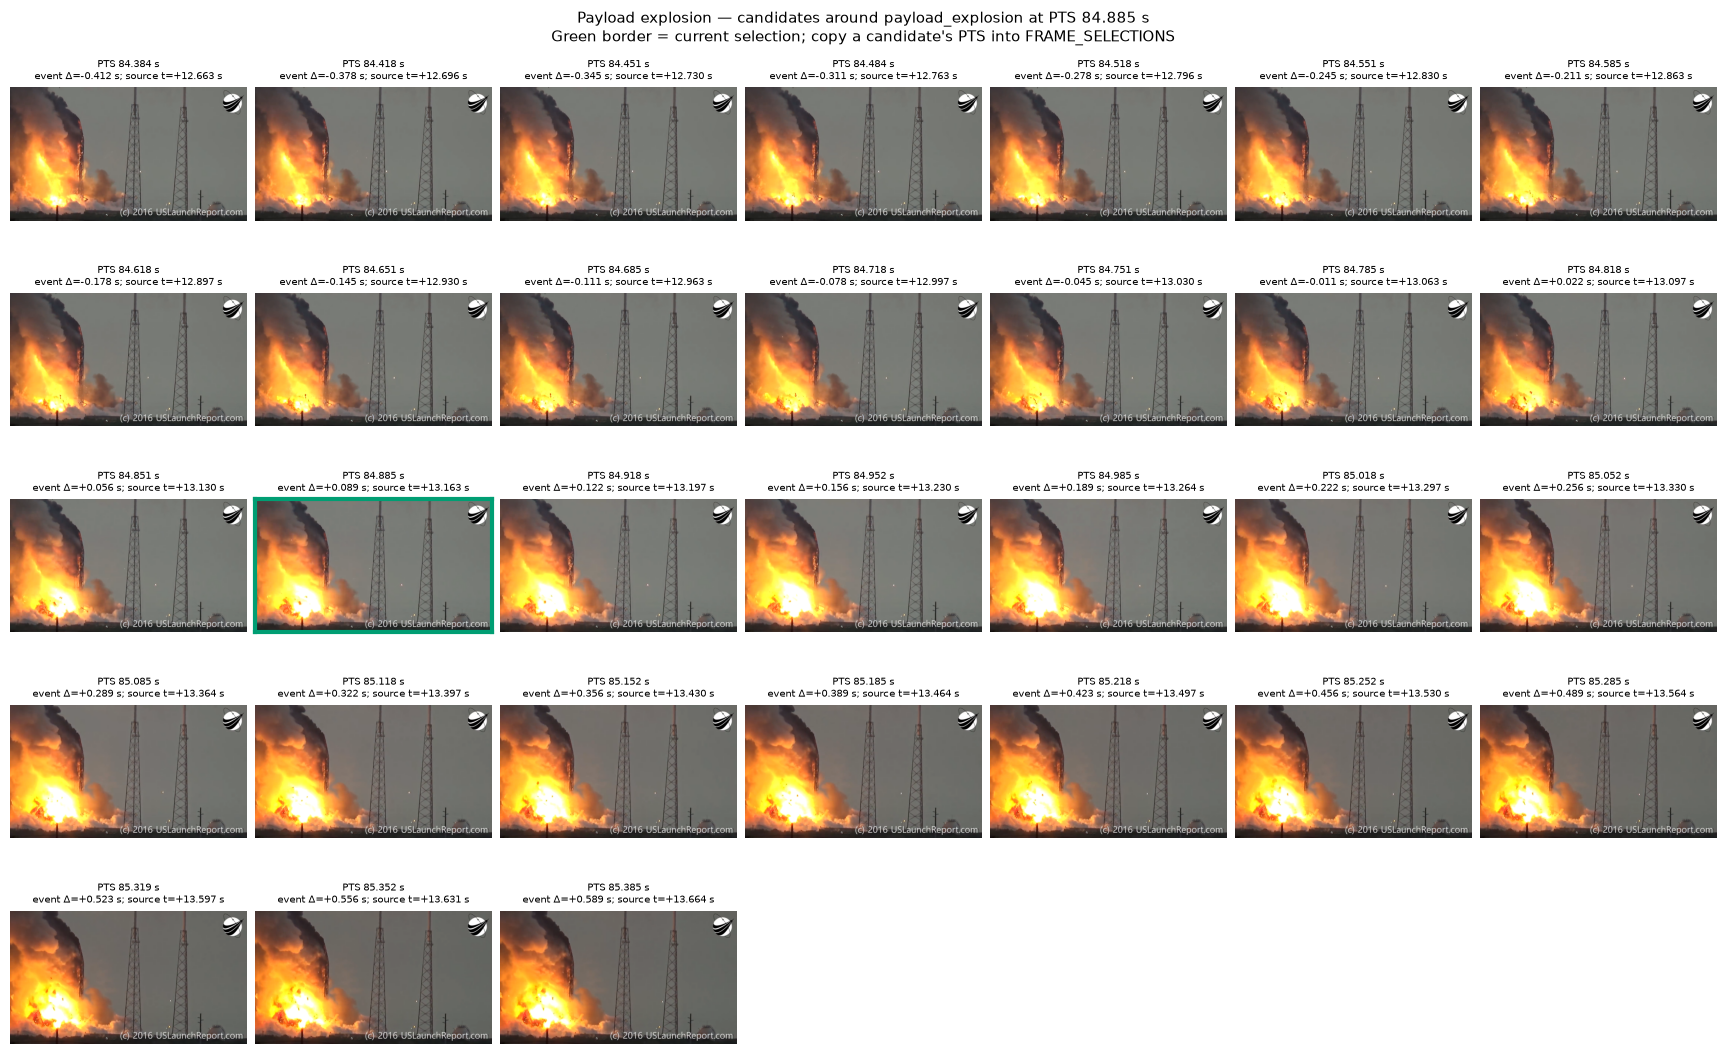

,selection_key,event_key,panel_label,candidate_index,currently_selected,requested_movie_pts_s,actual_movie_pts_s,frame_error_s,event_offset_s,source_offset_s
0,upper_stage_after,upper_stage,Upper-stage failure,0,False,71.537800,71.538133,0.000333,-0.183233,-0.183233
1,upper_stage_after,upper_stage,Upper-stage failure,1,False,71.571167,71.571500,0.000333,-0.149867,-0.149867
2,upper_stage_after,upper_stage,Upper-stage failure,2,False,71.604533,71.604867,0.000333,-0.116500,-0.116500
3,upper_stage_after,upper_stage,Upper-stage failure,3,False,71.637900,71.638233,0.000333,-0.083133,-0.083133
4,upper_stage_after,upper_stage,Upper-stage failure,4,False,71.671267,71.671600,0.000333,-0.049767,-0.049767
...,...,...,...,...,...,...,...,...,...,...
109,payload_fragments,payload_explosion,Payload explosion,26,False,85.252033,85.251833,0.000200,0.455967,13.530467
110,payload_fragments,payload_explosion,Payload explosion,27,False,85.285400,85.285200,0.000200,0.489333,13.563833
111,payload_fragments,payload_explosion,Payload explosion,28,False,85.318767,85.318567,0.000200,0.522700,13.597200
112,payload_fragments,payload_explosion,Payload explosion,29,False,85.352133,85.351933,0.000200,0.556067,13.630567


Contact sheets:
  /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/frame_selection_contact_sheets/165_frame_candidates_upper_stage_after.png
  /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/frame_selection_contact_sheets/165_frame_candidates_principal_explosion.png
  /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/frame_selection_contact_sheets/165_frame_candidates_falling_payload.png
  /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/frame_selection_contact_sheets/165_frame_candidates_payload_fragments.png


In [5]:
contact_sheet_files = []
contact_sheet_rows = []

if GENERATE_FRAME_CONTACT_SHEETS:
    for selection in FRAME_SELECTIONS:
        centre_pts_s = requested_movie_pts_s(selection)
        half_width_s = float(selection["candidate_half_width_s"])
        half_frame_count = int(np.ceil(half_width_s / native_frame_interval_s))
        requested_candidates_s = (
            centre_pts_s
            + np.arange(-half_frame_count, half_frame_count + 1)
            * native_frame_interval_s
        )

        candidates_by_pts = {}
        for requested_pts_s in requested_candidates_s:
            image, actual_pts_s, error_s = video_reader.frame_at_pts(
                float(requested_pts_s)
            )
            candidates_by_pts.setdefault(
                round(actual_pts_s, 9),
                {
                    "image": image,
                    "requested_movie_pts_s": float(requested_pts_s),
                    "actual_movie_pts_s": actual_pts_s,
                    "frame_error_s": error_s,
                },
            )

        candidates = list(candidates_by_pts.values())
        selected_index = int(
            np.argmin([
                abs(row["actual_movie_pts_s"] - centre_pts_s)
                for row in candidates
            ])
        )

        ncols = min(CONTACT_SHEET_COLUMNS, len(candidates))
        nrows = int(np.ceil(len(candidates) / ncols))
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(2.45 * ncols, 2.15 * nrows),
            constrained_layout=True,
        )
        axes = np.atleast_1d(axes).ravel()

        for candidate_index, (axis, row) in enumerate(zip(axes, candidates)):
            actual_pts_s = row["actual_movie_pts_s"]
            source_offset_s = (
                actual_pts_s - float(config.VIDEO_ANCHOR_MOVIE_S)
            )
            event_offset_s = (
                source_offset_s
                - event_source_offset_s(selection["event_key"])
            )
            axis.imshow(row["image"])
            axis.set_xticks([])
            axis.set_yticks([])
            axis.set_title(
                f"PTS {actual_pts_s:.3f} s\n"
                f"event Δ={event_offset_s:+.3f} s; "
                f"source t={source_offset_s:+.3f} s",
                fontsize=7.2,
            )
            selected = candidate_index == selected_index
            for spine in axis.spines.values():
                spine.set_visible(selected)
                spine.set_color("#009E73")
                spine.set_linewidth(3.0)
            contact_sheet_rows.append({
                "selection_key": selection["key"],
                "event_key": selection["event_key"],
                "panel_label": selection["panel_label"],
                "candidate_index": candidate_index,
                "currently_selected": selected,
                "requested_movie_pts_s": row["requested_movie_pts_s"],
                "actual_movie_pts_s": actual_pts_s,
                "frame_error_s": row["frame_error_s"],
                "event_offset_s": event_offset_s,
                "source_offset_s": source_offset_s,
            })

        for axis in axes[len(candidates):]:
            axis.set_visible(False)

        fig.suptitle(
            f"{selection['panel_label']} — candidates around "
            f"{selection['event_key']} "
            f"at PTS {selection['selected_movie_pts_s']:.3f} s\n"
            "Green border = current selection; copy a candidate's PTS "
            "into FRAME_SELECTIONS",
            fontsize=11,
        )
        contact_sheet_file = (
            CONTACT_SHEET_DIR
            / f"165_frame_candidates_{selection['key']}.png"
        )
        fig.savefig(
            contact_sheet_file,
            dpi=CONTACT_SHEET_DPI,
            bbox_inches="tight",
            facecolor="white",
        )
        contact_sheet_files.append(contact_sheet_file)
        plt.show()

    display(pd.DataFrame(contact_sheet_rows))
    print("Contact sheets:")
    for path in contact_sheet_files:
        print(" ", path)
else:
    print("GENERATE_FRAME_CONTACT_SHEETS=False; using current selections.")


### Manual selection checkpoint

Inspect the contact sheets above. If a different candidate is clearer, copy
its printed `PTS` value into that entry's `selected_movie_pts_s` near the top
of the notebook, then rerun from the controls cell. The candidate sheet still
reports its offset from the associated physical event for audit purposes, but
that derived offset is not the frame-selection control.


## 5. Extract the selected frames

The final frame audit retains the explicitly selected and actual decoded movie
PTS values, together with derived offsets from both the associated event and
the upper-stage source time. These derived offsets document the illustrative
frame choice; they do not redefine any physical event time.


In [6]:
video_frames = []
for panel_index, selection in enumerate(FRAME_SELECTIONS):
    requested_pts_s = requested_movie_pts_s(selection)
    image, actual_pts_s, error_s = video_reader.frame_at_pts(requested_pts_s)
    actual_source_offset_s = (
        actual_pts_s - float(config.VIDEO_ANCHOR_MOVIE_S)
    )
    actual_event_offset_s = (
        actual_source_offset_s
        - event_source_offset_s(selection["event_key"])
    )
    video_frames.append({
        "record_type": "video_frame",
        "panel": chr(ord("a") + panel_index),
        "selection_key": selection["key"],
        "label": selection["panel_label"],
        "description": selection["description"],
        "event_key": selection["event_key"],
        "selected_movie_pts_s": float(selection["selected_movie_pts_s"]),
        "requested_movie_pts_s": requested_pts_s,
        "actual_movie_pts_s": actual_pts_s,
        "frame_error_s": error_s,
        "actual_event_offset_s": actual_event_offset_s,
        "actual_source_offset_s": actual_source_offset_s,
        "image": image,
    })

frame_selection_table = pd.DataFrame([
    {key: value for key, value in row.items() if key != "image"}
    for row in video_frames
])
display(frame_selection_table)


,record_type,panel,selection_key,label,description,event_key,selected_movie_pts_s,requested_movie_pts_s,actual_movie_pts_s,frame_error_s,actual_event_offset_s,actual_source_offset_s
0,video_frame,a,upper_stage_after,Upper-stage failure,First visible upper-stage explosion,upper_stage,71.738,71.738,71.738333,0.000333,0.016967,0.016967
1,video_frame,b,principal_explosion,Principal explosion,Developed principal/lower-stage fireball,lower_stage,75.842,75.842,75.842433,0.000433,0.520467,4.121067
2,video_frame,c,falling_payload,Payload fall and impact,Payload/fairing close to the ground before impact,payload_impact,83.350,83.350,83.349933,0.000067,-0.878433,11.628567
3,video_frame,d,payload_fragments,Payload explosion,Developed payload fireball and ejected fragments,payload_explosion,84.885,84.885,84.884800,0.000200,0.088933,13.163433


## 6. Build Notebook-120-style event-centred pressure records

For every event and pressure channel, time zero is that channel's predicted
arrival using the adopted approximately 351 m s$^{-1}$ speed. A local median
from the reviewed baseline interval is removed, and the reviewed signal
interval is shaded. Each event keeps its own pressure scale.


In [7]:
def one_trace(channel: str):
    matches = [
        trace for trace in stream
        if trace.stats.channel.upper() == channel.upper()
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {[tr.id for tr in matches]}"
        )
    return matches[0].copy()


def one_window(source_event_key: str):
    matches = windows.loc[
        windows["source_event_key"].astype(str).eq(source_event_key)
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one reviewed window for {source_event_key}; "
            f"found {len(matches)}"
        )
    return matches.iloc[0]


pressure_records = {}
event_window_audit_rows = []

for event_key, event_label in EVENT_PLOT_SPECS:
    window = one_window(event_key)
    source_time = UTCDateTime(window["source_time_utc"])
    if abs(float(source_time - SOURCE_TIMES[event_key])) > 1e-6:
        raise ValueError(f"{event_key}: stale 110 source time; rerun 110 with current config")
    reference_arrival = UTCDateTime(window["predicted_reference_arrival_utc"])
    window_start = UTCDateTime(window["window_start_utc"])
    window_start_offset_s = float(window_start - reference_arrival)

    baseline_start_offset_s = (
        window_start_offset_s + float(window["baseline_start_s"])
    )
    baseline_end_offset_s = (
        window_start_offset_s + float(window["baseline_end_s"])
    )
    signal_start_offset_s = float(
        SIGNAL_START_OFFSET_OVERRIDES_S.get(
            event_key,
            window["signal_start_offset_from_predicted_arrival_s"],
        )
    )
    if event_key == "payload_impact" and not np.isclose(signal_start_offset_s, -0.04):
        raise ValueError("Rerun reviewed 110: payload impact support should start at -0.04 s")
    signal_end_offset_s = float(
        window["signal_end_offset_from_predicted_arrival_s"]
    )

    if not baseline_start_offset_s < baseline_end_offset_s <= signal_start_offset_s:
        raise ValueError(
            f"Baseline/signal overlap for {event_key}: "
            f"baseline={baseline_start_offset_s, baseline_end_offset_s}, "
            f"signal={signal_start_offset_s, signal_end_offset_s}"
        )

    override_xlim = EVENT_XLIMIT_OVERRIDES_S[event_key]
    plot_start_s, plot_end_s = (
        (baseline_start_offset_s, signal_end_offset_s)
        if override_xlim is None
        else tuple(map(float, override_xlim))
    )

    records = []
    for channel in PRESSURE_CHANNELS:
        distance_m = PRESSURE_DISTANCES_M[channel]
        predicted_arrival = (
            source_time + distance_m / ACOUSTIC_REDUCTION_SPEED_MPS
        )
        trace = one_trace(channel)
        times_s = np.asarray(
            trace.times(reftime=predicted_arrival), dtype=float
        )
        data_pa = np.asarray(trace.data, dtype=float)
        if np.ma.isMaskedArray(trace.data) or not np.isfinite(data_pa).all():
            raise ValueError(f"{trace.id}: missing/nonfinite waveform samples")
        if plot_start_s < times_s[0] or plot_end_s > times_s[-1]:
            raise ValueError(f"{event_key} {channel}: incomplete display support")
        finite = np.isfinite(times_s) & np.isfinite(data_pa)

        baseline_mask = (
            finite
            & (times_s >= baseline_start_offset_s)
            & (times_s <= baseline_end_offset_s)
        )
        plot_mask = (
            finite
            & (times_s >= plot_start_s)
            & (times_s <= plot_end_s)
        )
        if baseline_mask.sum() < 3 or plot_mask.sum() < 3:
            raise ValueError(
                f"Insufficient samples for {event_key} {channel}: "
                f"baseline={baseline_mask.sum()}, plot={plot_mask.sum()}"
            )

        baseline_pa = float(np.nanmedian(data_pa[baseline_mask]))
        records.append({
            "channel": channel,
            "time_s": times_s[plot_mask],
            "pressure_pa": data_pa[plot_mask] - baseline_pa,
            "baseline_pa": baseline_pa,
            "predicted_arrival_utc": str(predicted_arrival),
            "distance_m": distance_m,
        })

    pressure_records[event_key] = {
        "event_label": event_label,
        "source_time": source_time,
        "source_offset_s": float(source_time - UPPER_STAGE_UTC),
        "baseline_start_s": baseline_start_offset_s,
        "baseline_end_s": baseline_end_offset_s,
        "signal_start_s": signal_start_offset_s,
        "signal_end_s": signal_end_offset_s,
        "plot_start_s": plot_start_s,
        "plot_end_s": plot_end_s,
        "records": records,
    }
    event_window_audit_rows.append({
        "record_type": "event_window",
        "event_key": event_key,
        "event_label": event_label,
        "source_time_utc": str(source_time),
        "source_offset_s": float(source_time - UPPER_STAGE_UTC),
        "baseline_start_s": baseline_start_offset_s,
        "baseline_end_s": baseline_end_offset_s,
        "signal_start_s": signal_start_offset_s,
        "signal_end_s": signal_end_offset_s,
        "plot_start_s": plot_start_s,
        "plot_end_s": plot_end_s,
    })

display(pd.DataFrame(event_window_audit_rows))


,record_type,event_key,event_label,source_time_utc,source_offset_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,plot_start_s,plot_end_s
0,event_window,upper_stage,Upper-stage failure,2016-09-01T13:07:11.913000Z,0.0000,-0.82,-0.12,-0.07,0.48,-0.82,0.48
1,event_window,lower_stage,Principal explosion,2016-09-01T13:07:15.513600Z,3.6006,-1.35,-0.70,-0.70,1.05,-1.35,1.05
2,event_window,payload_impact,Payload impact,2016-09-01T13:07:24.420000Z,12.5070,-0.12,-0.05,-0.04,0.33,-0.12,0.33
3,event_window,payload_explosion,Payload explosion,2016-09-01T13:07:24.987500Z,13.0745,-0.13,-0.03,-0.03,0.27,-0.13,0.27


## 8. Generate the 2×2 publication composite

Each of the four lettered panels is a self-contained event column containing a
large unobstructed video frame above its event-centred DD1–DD3 pressure
waveforms. Exact movie PTS values remain in the audit rather than appearing in
the figure. The inferred physical event time is printed above each pressure
axis, and the dotted vertical line marks the predicted channel-specific
acoustic arrival—not the video-frame time or an observed pressure peak.


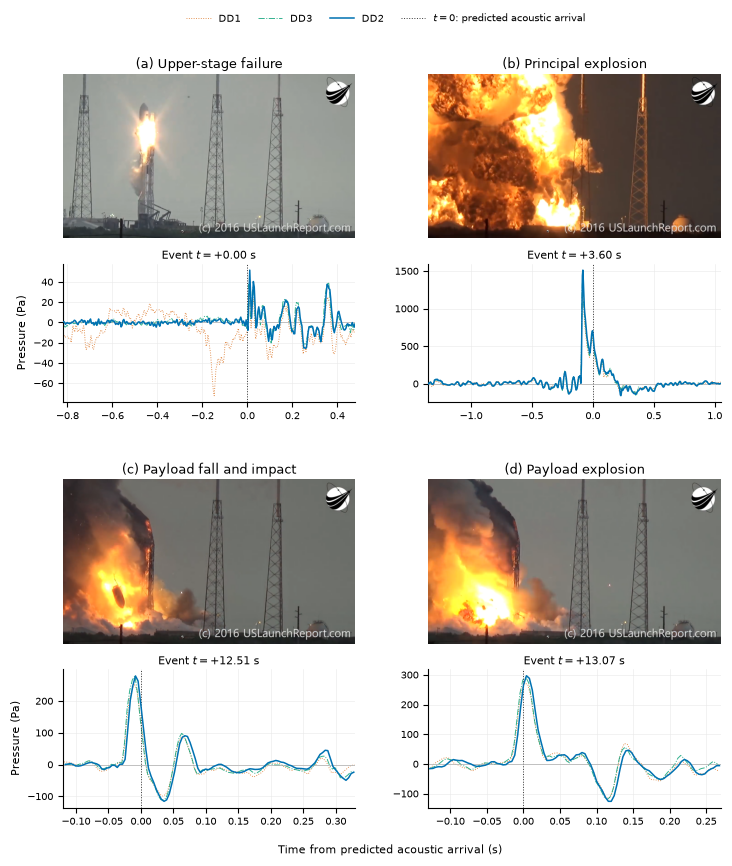

Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/165_video_named_event_waveforms.pdf
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/165_video_named_event_waveforms.png


In [8]:
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

if len(video_frames) != 4 or len(EVENT_PLOT_SPECS) != 4:
    raise ValueError(
        "The 2x2 composite requires exactly four video frames and four "
        "waveform events."
    )

fig = plt.figure(figsize=(7.35, 8.8), constrained_layout=False)
outer = GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.2,
    wspace=0.25,
    left=0.09,
    right=0.985,
    bottom=0.08,
    top=0.925,
)

pressure_axes = []

for event_index, ((event_key, event_label), frame_record) in enumerate(
    zip(EVENT_PLOT_SPECS, video_frames)
):
    row, column = divmod(event_index, 2)

    panel_grid = outer[row, column].subgridspec(
        2,
        1,
        height_ratios=(1.33, 1.00),
        hspace=0.10,
    )

    # Large, unobstructed video frame.
    image_axis = fig.add_subplot(panel_grid[0])
    image_axis.imshow(frame_record["image"])
    image_axis.set_xticks([])
    image_axis.set_yticks([])
    for spine in image_axis.spines.values():
        spine.set_visible(False)
    panel_letter = chr(ord("a") + event_index)
    image_axis.set_title(
        f"({panel_letter}) {frame_record['label']}",
        pad=4,
        fontsize=9,
    )

    # Event-centred pressure waveforms.
    pressure_axis = fig.add_subplot(panel_grid[1])
    pressure_axes.append(pressure_axis)
    event = pressure_records[event_key]

    records_by_channel = {
        record["channel"]: record for record in event["records"]
    }
    if set(records_by_channel) != set(PRESSURE_PLOT_ORDER):
        raise ValueError(
            f"Unexpected pressure channels for {event_key}: "
            f"{sorted(records_by_channel)}"
        )
    # Draw DD2 last so the highest-quality record remains unobscured.
    for channel in PRESSURE_PLOT_ORDER:
        record = records_by_channel[channel]
        pressure_axis.plot(
            record["time_s"],
            record["pressure_pa"],
            label=channel,
            **PRESSURE_LINE_STYLES[channel],
        )

    pressure_axis.axvline(0.0, color="0.22", lw=0.70, ls=":")
    pressure_axis.axhline(0.0, color="0.68", lw=0.50)
    pressure_axis.set_xlim(event["plot_start_s"], event["plot_end_s"])
    pressure_axis.grid(True, color="0.91", linewidth=0.40)
    pressure_axis.spines["top"].set_visible(False)
    pressure_axis.spines["right"].set_visible(False)
    pressure_axis.set_title(
        f"Event $t={event['source_offset_s']:+.2f}$ s",
        pad=3,
        fontsize=7.8,
    )
    if column == 0:
        pressure_axis.set_ylabel("Pressure (Pa)")

# One shared legend for all four pressure panels.
pressure_handles, pressure_labels = pressure_axes[0].get_legend_handles_labels()
arrival_handle = Line2D(
    [0],
    [0],
    color="0.22",
    lw=0.70,
    ls=":",
    label=r"$t=0$: predicted acoustic arrival",
)
fig.legend(
    pressure_handles + [arrival_handle],
    pressure_labels + [r"$t=0$: predicted acoustic arrival"],
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.992),
    ncol=4,
    columnspacing=1.8,
    handlelength=2.5,
)

fig.text(
    0.535,
    0.025,
    "Time from predicted acoustic arrival (s)",
    ha="center",
    va="bottom",
    fontsize=8,
)

fig.savefig(FIGURE_FILE, format="pdf", bbox_inches="tight")
fig.savefig(
    FIGURE_PREVIEW_FILE,
    dpi=FINAL_FIGURE_DPI,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print("Saved:", FIGURE_FILE)
print("Saved:", FIGURE_PREVIEW_FILE)


## 9. Write frame/window audit and provenance

The audit distinguishes the requested visual offset from the actual decoded
native-frame time. The provenance also records every editable frame-selection
control, the contact sheets, waveform-window settings, and whether the optional
seismic row was enabled.


In [9]:
frame_audit = frame_selection_table.copy()
window_audit = pd.DataFrame(event_window_audit_rows)
audit_columns = sorted(set(frame_audit.columns) | set(window_audit.columns))
audit = pd.concat(
    [
        frame_audit.reindex(columns=audit_columns),
        window_audit.reindex(columns=audit_columns),
    ],
    ignore_index=True,
)
audit.to_csv(AUDIT_FILE, index=False)

provenance = {
    "producer_notebook": "165_generate_video_waveform_figure.ipynb",
    "input_fingerprints": {str(path): file_fingerprint(path) for path in
        (VIDEO_FILE, WAVEFORM_FILE, GEOMETRY_FILE, WEATHER_FILE, WINDOW_FILE, MEASUREMENT_METADATA_FILE)},
    "figure_file": str(FIGURE_FILE),
    "figure_preview_file": str(FIGURE_PREVIEW_FILE),
    "audit_file": str(AUDIT_FILE),
    "contact_sheet_files": [str(path) for path in contact_sheet_files],
    "video_file": str(VIDEO_FILE),
    "video_redistributed": False,
    "video_anchor_movie_s": float(config.VIDEO_ANCHOR_MOVIE_S),
    "video_anchor_utc": str(config.VIDEO_ANCHOR_UTC),
    "video_nominal_fps_config": float(config.VIDEO_NOMINAL_FPS),
    "video_nominal_fps_decoded": float(video_reader.nominal_fps),
    "waveform_file": str(WAVEFORM_FILE),
    "geometry_file": str(GEOMETRY_FILE),
    "weather_file": str(WEATHER_FILE),
    "measurement_windows_file": str(WINDOW_FILE),
    "measurement_metadata_file": str(MEASUREMENT_METADATA_FILE),
    "meteorological_effective_speed_mps": meteorological_speed_mps,
    "adopted_acoustic_reduction_speed_mps": ACOUSTIC_REDUCTION_SPEED_MPS,
    "pressure_channels": list(PRESSURE_CHANNELS),
    "pressure_plot_order": list(PRESSURE_PLOT_ORDER),
    "pressure_line_styles": PRESSURE_LINE_STYLES,
    "pressure_filter": None,
    "pressure_processing": "010 calibrated moving-median baseline, then sensor-relative local median",
    "baseline_endpoint_convention": "inclusive samples in sensor-relative 124-style display windows",
    "time_zero": "each sensor predicted arrival, not DD2 observed time or movie frame",
    "waveforms_are_display_products_not_replacement_110_measurements": True,
    "include_seismic": INCLUDE_SEISMIC,
    "seismic_channels": list(SEISMIC_CHANNELS) if INCLUDE_SEISMIC else [],
    "seismic_filter": None,
    "seismic_constant_median_removed_for_display": (
        REMOVE_SEISMIC_DISPLAY_MEDIAN if INCLUDE_SEISMIC else False
    ),
    "source_event_times_utc": {
        key: str(value) for key, value in SOURCE_TIMES.items()
    },
    "frame_selections": [
        {
            key: value for key, value in selection.items()
            if key != "candidate_half_width_s"
        }
        | {
            "candidate_half_width_s": float(
                selection["candidate_half_width_s"]
            )
        }
        for selection in FRAME_SELECTIONS
    ],
    "decoded_frame_selection": frame_selection_table.to_dict(orient="records"),
    "event_xlim_overrides_s": EVENT_XLIMIT_OVERRIDES_S,
    "signal_start_offset_overrides_s": SIGNAL_START_OFFSET_OVERRIDES_S,
}
PROVENANCE_FILE.write_text(json.dumps(provenance, indent=2) + "\n")

video_reader.close()

display(audit)
print("Saved:", AUDIT_FILE)
print("Saved:", PROVENANCE_FILE)


,actual_event_offset_s,actual_movie_pts_s,actual_source_offset_s,baseline_end_s,baseline_start_s,description,event_key,event_label,frame_error_s,label,...,plot_end_s,plot_start_s,record_type,requested_movie_pts_s,selected_movie_pts_s,selection_key,signal_end_s,signal_start_s,source_offset_s,source_time_utc
0,0.016967,71.738333,0.016967,NaN,NaN,First visible upper-stage explosion,upper_stage,NaN,0.000333,Upper-stage failure,...,NaN,NaN,video_frame,71.738,71.738,upper_stage_after,NaN,NaN,NaN,NaN
1,0.520467,75.842433,4.121067,NaN,NaN,Developed principal/lower-stage fireball,lower_stage,NaN,0.000433,Principal explosion,...,NaN,NaN,video_frame,75.842,75.842,principal_explosion,NaN,NaN,NaN,NaN
2,-0.878433,83.349933,11.628567,NaN,NaN,Payload/fairing close to the ground before impact,payload_impact,NaN,0.000067,Payload fall and impact,...,NaN,NaN,video_frame,83.350,83.350,falling_payload,NaN,NaN,NaN,NaN
3,0.088933,84.884800,13.163433,NaN,NaN,Developed payload fireball and ejected fragments,payload_explosion,NaN,0.000200,Payload explosion,...,NaN,NaN,video_frame,84.885,84.885,payload_fragments,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,-0.12,-0.82,NaN,upper_stage,Upper-stage failure,NaN,NaN,...,0.48,-0.82,event_window,NaN,NaN,NaN,0.48,-0.07,0.0000,2016-09-01T13:07:11.913000Z
5,NaN,NaN,NaN,-0.70,-1.35,NaN,lower_stage,Principal explosion,NaN,NaN,...,1.05,-1.35,event_window,NaN,NaN,NaN,1.05,-0.70,3.6006,2016-09-01T13:07:15.513600Z
6,NaN,NaN,NaN,-0.05,-0.12,NaN,payload_impact,Payload impact,NaN,NaN,...,0.33,-0.12,event_window,NaN,NaN,NaN,0.33,-0.04,12.5070,2016-09-01T13:07:24.420000Z
7,NaN,NaN,NaN,-0.03,-0.13,NaN,payload_explosion,Payload explosion,NaN,NaN,...,0.27,-0.13,event_window,NaN,NaN,NaN,0.27,-0.03,13.0745,2016-09-01T13:07:24.987500Z


Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/165_video_named_event_waveforms_audit.csv
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/165_generate_video_waveform_figure/165_video_named_event_waveforms_provenance.json


## Suggested caption

**Selected visual states and event-centred infrasound waveforms of the opening
failure sequence.** Each composite panel pairs a manually selected unobstructed
frame from the USLaunchReport recording with the corresponding
baseline-corrected DD1–DD3 pressure records: (a) upper-stage failure, (b)
principal explosion, (c) payload descent and impact, and (d) payload
explosion. Frames were selected for visual clarity and do not, in general,
represent the independently inferred physical origin times; exact movie
presentation timestamps are retained in the accompanying audit. DD2 (solid
blue) is emphasized because it provides the highest-quality pressure record;
DD1 (orange dotted) and DD3 (green dash-dotted) are retained for intersensor
comparison. For every trace, the vertical dotted line at zero is the predicted
channel-specific acoustic arrival calculated using the adopted approximately
351 m s$^{-1}$ effective sound speed; it is not the video-frame time or an
observed pressure peak. Each event has an independent pressure and time scale.
Movie frames © USLaunchReport.com/Michael Wagner, reproduced with permission.
The video has no independent absolute UTC clock and is aligned to the
geophysical chronology using the upper-stage event.
